In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

df = pd.read_csv(filename)
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Saving train_preprocessed_lowercased.csv to train_preprocessed_lowercased.csv
Uploaded file: train_preprocessed_lowercased.csv
Dataset Shape: (159571, 3)

First 5 rows:


,id,comment_text,toxic
0,0000997932d777bf,explanation\nwhy the edits made under my usern...,0
1,000103f0d9cfb60f,d'aww! he matches this background colour i'm s...,0
2,000113f07ec002fd,"hey man, i'm really not trying to edit war. it...",0
3,0001b41b1c6bb37e,"""\nmore\ni can't make any real suggestions on ...",0
4,0001d958c54c6e35,"you, sir, are my hero. any chance you remember...",0


EDA - BEFORE PREPROCESSING
Average comment length: 394.14
Average word count: 67.27
Average punctuation: 15.89


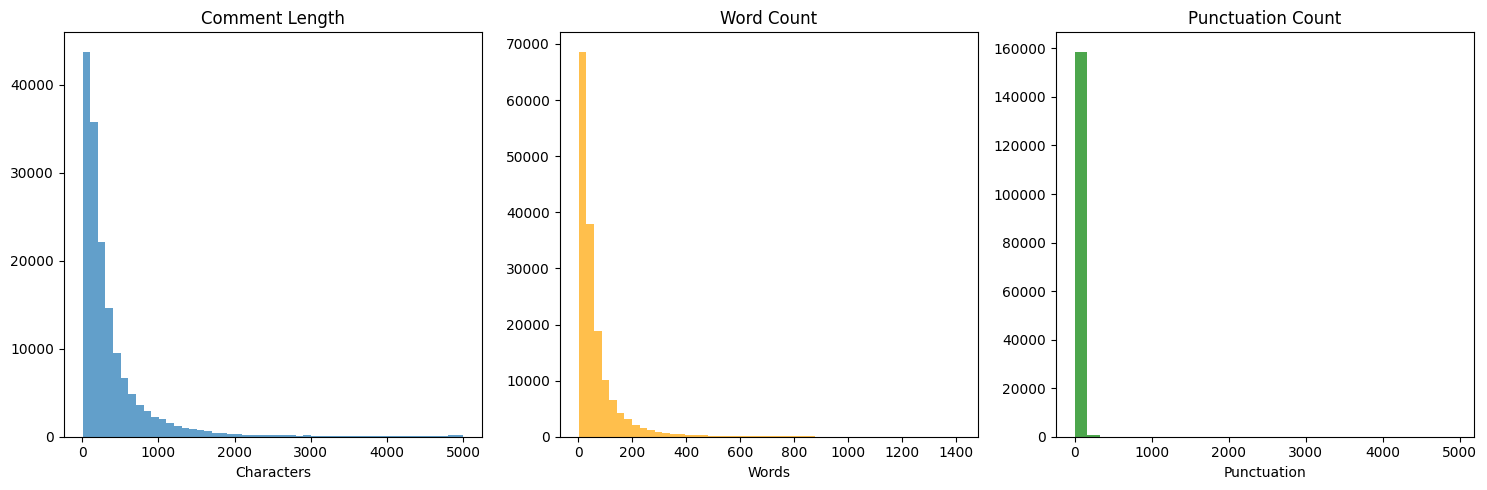

In [4]:
import string
import matplotlib.pyplot as plt

print("EDA - BEFORE PREPROCESSING")
print("="*50)

df['comment_length'] = df['comment_text'].str.len()
df['word_count'] = df['comment_text'].str.split().str.len()
df['punctuation_count'] = df['comment_text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

print(f"Average comment length: {df['comment_length'].mean():.2f}")
print(f"Average word count: {df['word_count'].mean():.2f}")
print(f"Average punctuation: {df['punctuation_count'].mean():.2f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['comment_length'], bins=50, alpha=0.7)
plt.title('Comment Length')
plt.xlabel('Characters')

plt.subplot(1, 3, 2)
plt.hist(df['word_count'], bins=50, alpha=0.7, color='orange')
plt.title('Word Count')
plt.xlabel('Words')

plt.subplot(1, 3, 3)
plt.hist(df['punctuation_count'], bins=30, alpha=0.7, color='green')
plt.title('Punctuation Count')
plt.xlabel('Punctuation')

plt.tight_layout()
plt.show()

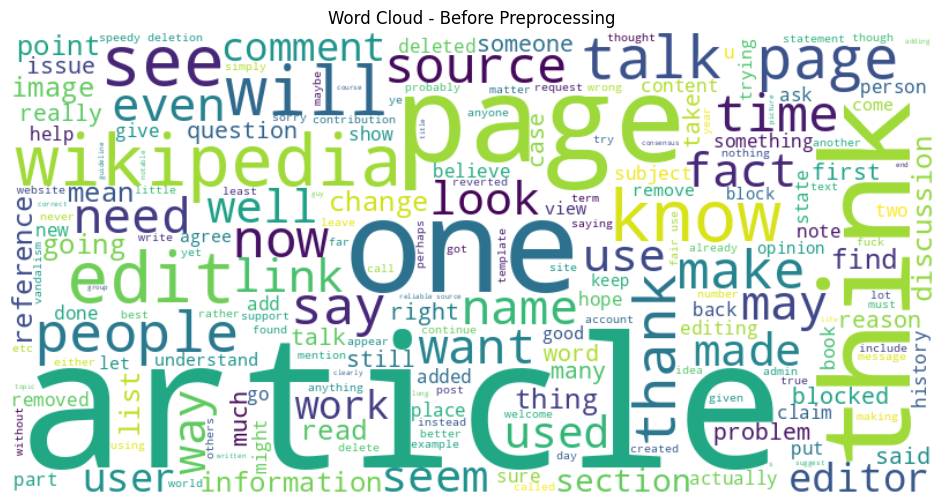

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text_before = ' '.join(df['comment_text'].astype(str))
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(all_text_before)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Before Preprocessing')
plt.show()

In [8]:
import re
import pandas as pd

def remove_punctuation(text):
    if pd.isna(text):
        return ""
    text = str(text)
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

df['comment_text_processed'] = df['comment_text'].apply(remove_punctuation)

print("Preprocessing examples:")
for i in range(3):
    print(f"\nOriginal:  {df['comment_text'].iloc[i]}")
    print(f"Processed: {df['comment_text_processed'].iloc[i]}")

Preprocessing examples:

Original:  explanation
why the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now.89.205.38.27
Processed: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now892053827

Original:  d'aww! he matches this background colour i'm seemingly stuck with. thanks.  (talk) 21:51, january 11, 2016 (utc)
Processed: daww he matches this background colour im seemingly stuck with thanks talk 2151 january 11 2016 utc

Original:  hey man, i'm really not trying to edit war. it's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. he seems to care

EDA - AFTER PREPROCESSING
Average comment length: 373.52
Average word count: 66.13
Length reduction: 20.62


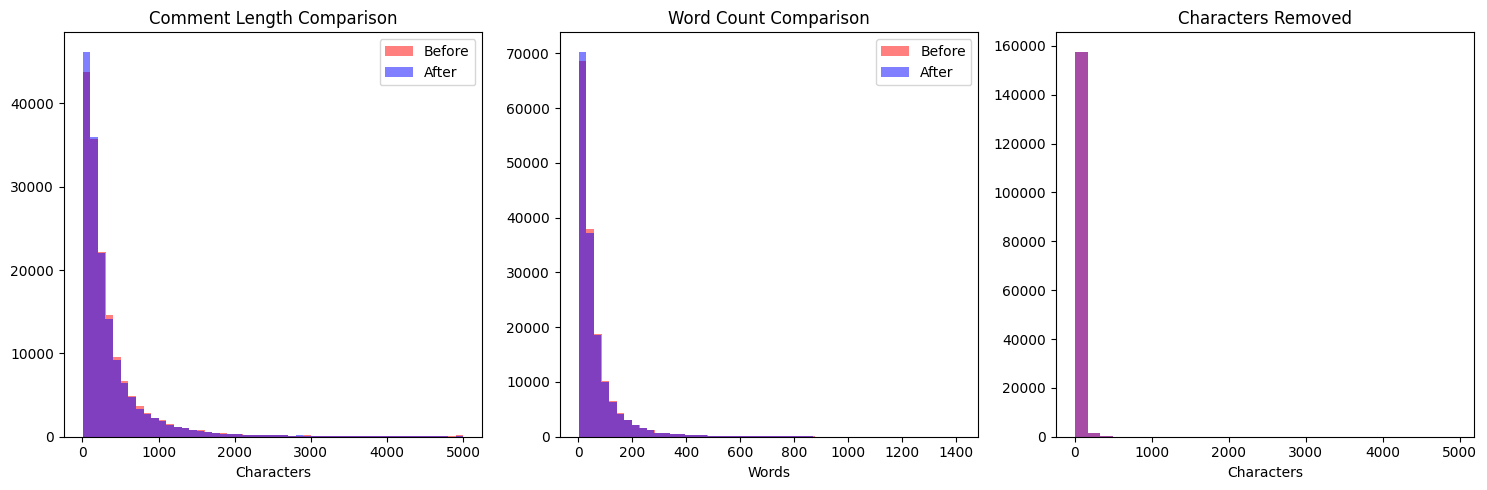

In [9]:
print("EDA - AFTER PREPROCESSING")
print("="*50)

df['comment_length_processed'] = df['comment_text_processed'].str.len()
df['word_count_processed'] = df['comment_text_processed'].str.split().str.len()

print(f"Average comment length: {df['comment_length_processed'].mean():.2f}")
print(f"Average word count: {df['word_count_processed'].mean():.2f}")
print(f"Length reduction: {(df['comment_length'].mean() - df['comment_length_processed'].mean()):.2f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['comment_length'], bins=50, alpha=0.5, label='Before', color='red')
plt.hist(df['comment_length_processed'], bins=50, alpha=0.5, label='After', color='blue')
plt.title('Comment Length Comparison')
plt.xlabel('Characters')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(df['word_count'], bins=50, alpha=0.5, label='Before', color='red')
plt.hist(df['word_count_processed'], bins=50, alpha=0.5, label='After', color='blue')
plt.title('Word Count Comparison')
plt.xlabel('Words')
plt.legend()

plt.subplot(1, 3, 3)
length_reduction = df['comment_length'] - df['comment_length_processed']
plt.hist(length_reduction, bins=30, alpha=0.7, color='purple')
plt.title('Characters Removed')
plt.xlabel('Characters')

plt.tight_layout()
plt.show()

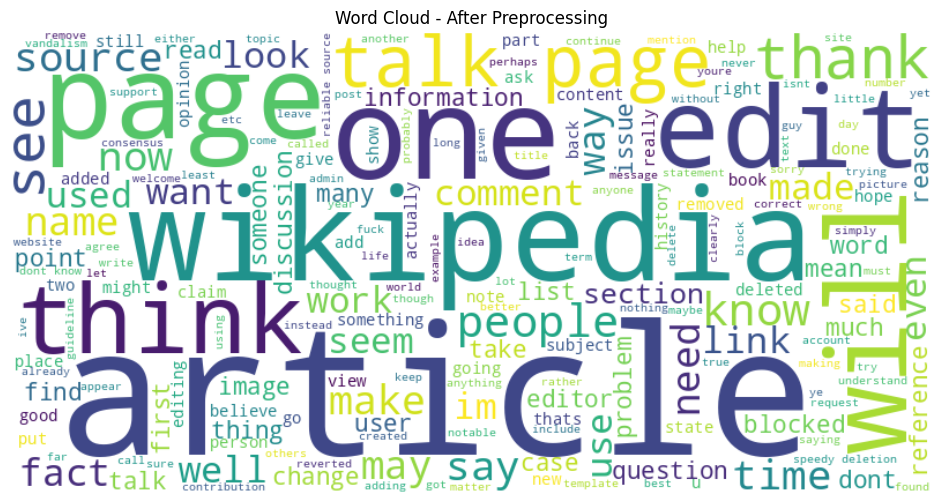

Top 10 words after preprocessing:
1. the - 495403
2. to - 296839
3. of - 224012
4. and - 222339
5. a - 214197
6. you - 204489
7. i - 200516
8. is - 175949
9. that - 154274
10. in - 144156

Dataset saved as 'Remove punctuation and special characters.csv'


In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

all_text_after = ' '.join(df['comment_text_processed'].astype(str))
wordcloud_after = WordCloud(width=800, height=400, background_color='white').generate(all_text_after)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - After Preprocessing')
plt.show()

all_words = ' '.join(df['comment_text_processed']).lower().split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

print("Top 10 words after preprocessing:")
for i, (word, count) in enumerate(common_words, 1):
    print(f"{i}. {word} - {count}")

df.to_csv('Remove punctuation and special characters.csv', index=False)
print("\nDataset saved as 'Remove punctuation and special characters.csv'")